# Pharmacy Sales — SARIMA Forecasting Model

**Data Pipeline:**
1. ✅ `data_cleaning.ipynb` - Cleaned data (outliers handled, 100% quality)
2. ✅ `pharmacy_sales_feature_engineering.ipynb` - Created train/test splits
3. ✅ `pharmacy_sales_baseline_models.ipynb` - Established benchmarks
4. 📍 **This notebook** - SARIMA advanced statistical model

**Temporal Split (matches feature engineering):**
| Split | Years | Purpose |
|-------|-------|---------|
| **Training** | 2014–2023 | Learn historical demand patterns |
| **Validation** | 2024–2025 | Evaluate model, compare vs baseline |

**Built to handle:**
- ⚠ Low-volume drugs (WMAPE used as primary metric, not MAPE)
- ⚠ Shifting demand (structural break detection before fitting)
- Per-drug individual SARIMA models

**Benchmark to beat (Holt-Winters, 2024–2025 validation):**
> Loaded dynamically from `results/baseline_models/baseline_summary.csv`

**Success Criteria:** SARIMA must achieve lower MAE than Holt-Winters on the 2024–2025 validation set


In [1]:
import sys, os
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)
print(f'✓ Project root: {project_root}')

✓ Project root: /home/brenda/final year project/PharmacyForecastingSystem


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import pickle

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

try:
    from pmdarima import auto_arima
    AUTO_ARIMA_AVAILABLE = True
    print('✓ pmdarima available — will use auto_arima')
except ImportError:
    AUTO_ARIMA_AVAILABLE = False
    print('⚠ pmdarima not installed — using manual grid search')
    print('  Install: pip install pmdarima')

try:
    from ruptures import Binseg
    RUPTURES_AVAILABLE = True
    print('✓ ruptures available — structural break detection enabled')
except ImportError:
    RUPTURES_AVAILABLE = False
    print('⚠ ruptures not installed — using simple fallback')
    print('  Install: pip install ruptures')

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
print('✓ All imports done')

✓ pmdarima available — will use auto_arima
✓ ruptures available — structural break detection enabled
✓ All imports done


## 1. LOAD DATA

**Data Source:** Same train/test splits as baseline models from `pharmacy_sales_feature_engineering.ipynb`
- **Training:** 2014–2023 (~520 weeks per drug)
- **Validation:** 2024–2025 (~104 weeks per drug)
- Proper temporal split — no data leakage
- Selected drugs with sufficient history


In [3]:
from pathlib import Path

data_dir = Path(project_root) / 'data' / 'processed'

print("Loading data from feature engineering pipeline...")
print(f"Source: {data_dir}")

# Load the same data as baseline models
train_df = pd.read_csv(data_dir / 'train_baseline.csv', parse_dates=['week_start_date'])
test_df  = pd.read_csv(data_dir / 'test_baseline.csv', parse_dates=['week_start_date'])

# Get unique drugs from the data
selected_drugs = sorted(train_df['drug_name'].unique().tolist())

full_df = pd.concat([train_df, test_df]).sort_values(['drug_name','week_start_date'])

print('\n' + '=' * 60)
print('DATA LOADED FROM FEATURE ENGINEERING')
print('=' * 60)
print(f'Train : {len(train_df):,} rows  ({train_df.week_start_date.min().date()} to {train_df.week_start_date.max().date()})')
print(f'Test  : {len(test_df):,}  rows  ({test_df.week_start_date.min().date()} to {test_df.week_start_date.max().date()})')
print(f'Drugs : {len(selected_drugs)}')
print(f'Selected drugs: {", ".join(selected_drugs)}')

# ── Baseline benchmarks (Holt-Winters on 2024-2025 validation) ───────────
baseline_results_path = Path(project_root) / 'data' / 'results' / 'baseline_models' / 'baseline_summary.csv'
try:
    _bl = pd.read_csv(baseline_results_path)
    _hw = _bl[_bl['Model_Type'] == 'Holt-Winters'].iloc[0]
    BASELINE_MAE   = round(float(_hw['MAE']),   4)
    BASELINE_RMSE  = round(float(_hw['RMSE']),  4)
    BASELINE_MAPE  = round(float(_hw['MAPE']),  4)
    BASELINE_R2    = round(float(_hw['R2']),     4)
    print(f'\n✓ Baseline metrics loaded from {baseline_results_path.name}')
except Exception as e:
    # Fallback values — re-run pharmacy_sales_baseline_models.ipynb to update
    BASELINE_MAE   = 7.9391
    BASELINE_RMSE  = 10.3778
    BASELINE_MAPE  = 30.3046
    BASELINE_R2    = -0.4835
    print(f'\n⚠ Could not load baseline file ({e})')
    print(f'  Using fallback values — run baseline notebook to get exact 2024-2025 figures')

print(f'\n{"=" * 60}')
print('BENCHMARK TO BEAT (Holt-Winters, 2024-2025 validation)')
print('=' * 60)
print(f'MAE: {BASELINE_MAE} | RMSE: {BASELINE_RMSE} | MAPE: {BASELINE_MAPE}% | R²: {BASELINE_R2}')
print(f'\n✓ Using cleaned data with outliers handled')
print(f'✓ Same data pipeline as baseline models for fair comparison')


Loading data from feature engineering pipeline...
Source: /home/brenda/final year project/PharmacyForecastingSystem/data/processed

DATA LOADED FROM FEATURE ENGINEERING
Train : 4,140 rows  (2013-12-30 to 2023-12-25)
Test  : 832  rows  (2024-01-01 to 2025-12-22)
Drugs : 8
Selected drugs: M01AB, M01AE, N02BA, N02BE, N05B, N05C, R03, R06

✓ Baseline metrics loaded from baseline_summary.csv

BENCHMARK TO BEAT (Holt-Winters, 2024-2025 validation)
MAE: 7.7541 | RMSE: 10.5458 | MAPE: inf% | R²: 0.0958

✓ Using cleaned data with outliers handled
✓ Same data pipeline as baseline models for fair comparison


## 2. DRUG SEGMENTATION BY VOLUME

Low-volume drugs massively inflate MAPE. We separate them to report metrics fairly.

=== DRUG VOLUME SEGMENTATION ===
segment
High Volume      3
Low Volume       1
Medium Volume    4
Name: drug_name, dtype: int64



,drug_name,mean_qty,median_qty,cv,segment
3,N02BE,111.6801,113.0000,0.0703,High Volume
4,N05B,57.6973,55.0000,0.3574,High Volume
6,R03,55.7107,50.0000,0.5728,High Volume
0,M01AB,36.5920,36.0000,0.2413,Medium Volume
1,M01AE,26.6897,26.0000,0.2598,Medium Volume
7,R06,23.8046,20.0000,0.6028,Medium Volume
2,N02BA,22.2222,22.0000,0.4218,Medium Volume
5,N05C,4.5802,4.0000,0.6344,Low Volume


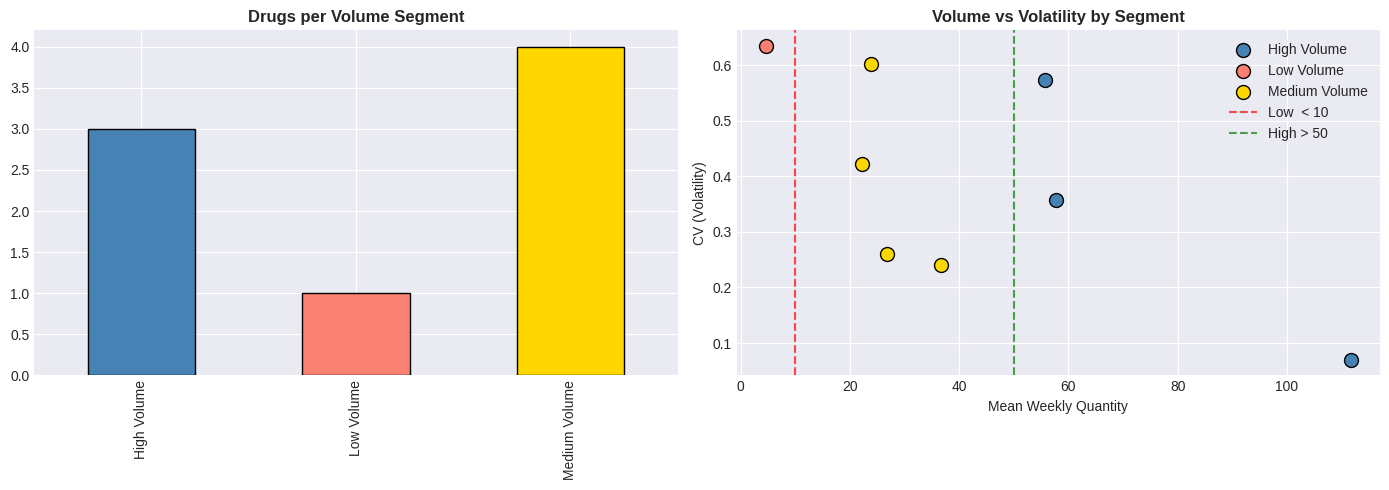

In [4]:
# Compute per-drug stats on training data
drug_stats = train_df.groupby('drug_name')['total_quantity'].agg(
    mean_qty='mean', median_qty='median', std_qty='std', weeks='count'
).reset_index()

drug_stats['cv'] = drug_stats['std_qty'] / drug_stats['mean_qty']

# ── Adjust these thresholds based on your printout above ──
LOW_VOL_THRESHOLD  = 10   # avg weekly qty < 10 = low volume
HIGH_VOL_THRESHOLD = 50   # avg weekly qty > 50 = high volume

def segment(row):
    if row['mean_qty'] < LOW_VOL_THRESHOLD:
        return 'Low Volume'
    elif row['mean_qty'] >= HIGH_VOL_THRESHOLD:
        return 'High Volume'
    return 'Medium Volume'

drug_stats['segment'] = drug_stats.apply(segment, axis=1)
seg_map = drug_stats.set_index('drug_name')['segment'].to_dict()

print('=== DRUG VOLUME SEGMENTATION ===')
print(drug_stats.groupby('segment')['drug_name'].count())
print()
display(drug_stats[['drug_name','mean_qty','median_qty','cv','segment']].sort_values('mean_qty', ascending=False))

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {'Low Volume':'salmon', 'Medium Volume':'gold', 'High Volume':'steelblue'}

drug_stats.groupby('segment')['drug_name'].count().plot(
    kind='bar', ax=axes[0],
    color=[colors[s] for s in drug_stats.groupby('segment')['drug_name'].count().index],
    edgecolor='black'
)
axes[0].set_title('Drugs per Volume Segment', fontweight='bold')
axes[0].set_xlabel('')

for seg, grp in drug_stats.groupby('segment'):
    axes[1].scatter(grp['mean_qty'], grp['cv'], label=seg, color=colors[seg], s=100, edgecolors='black')
axes[1].axvline(LOW_VOL_THRESHOLD,  color='red',   linestyle='--', alpha=0.7, label=f'Low  < {LOW_VOL_THRESHOLD}')
axes[1].axvline(HIGH_VOL_THRESHOLD, color='green',  linestyle='--', alpha=0.7, label=f'High > {HIGH_VOL_THRESHOLD}')
axes[1].set_xlabel('Mean Weekly Quantity'); axes[1].set_ylabel('CV (Volatility)')
axes[1].set_title('Volume vs Volatility by Segment', fontweight='bold')
axes[1].legend()
plt.tight_layout(); plt.show()

## 3. STRUCTURAL BREAK DETECTION

Detects when demand shifted. SARIMA is fitted only on **post-break** data to avoid learning outdated patterns.

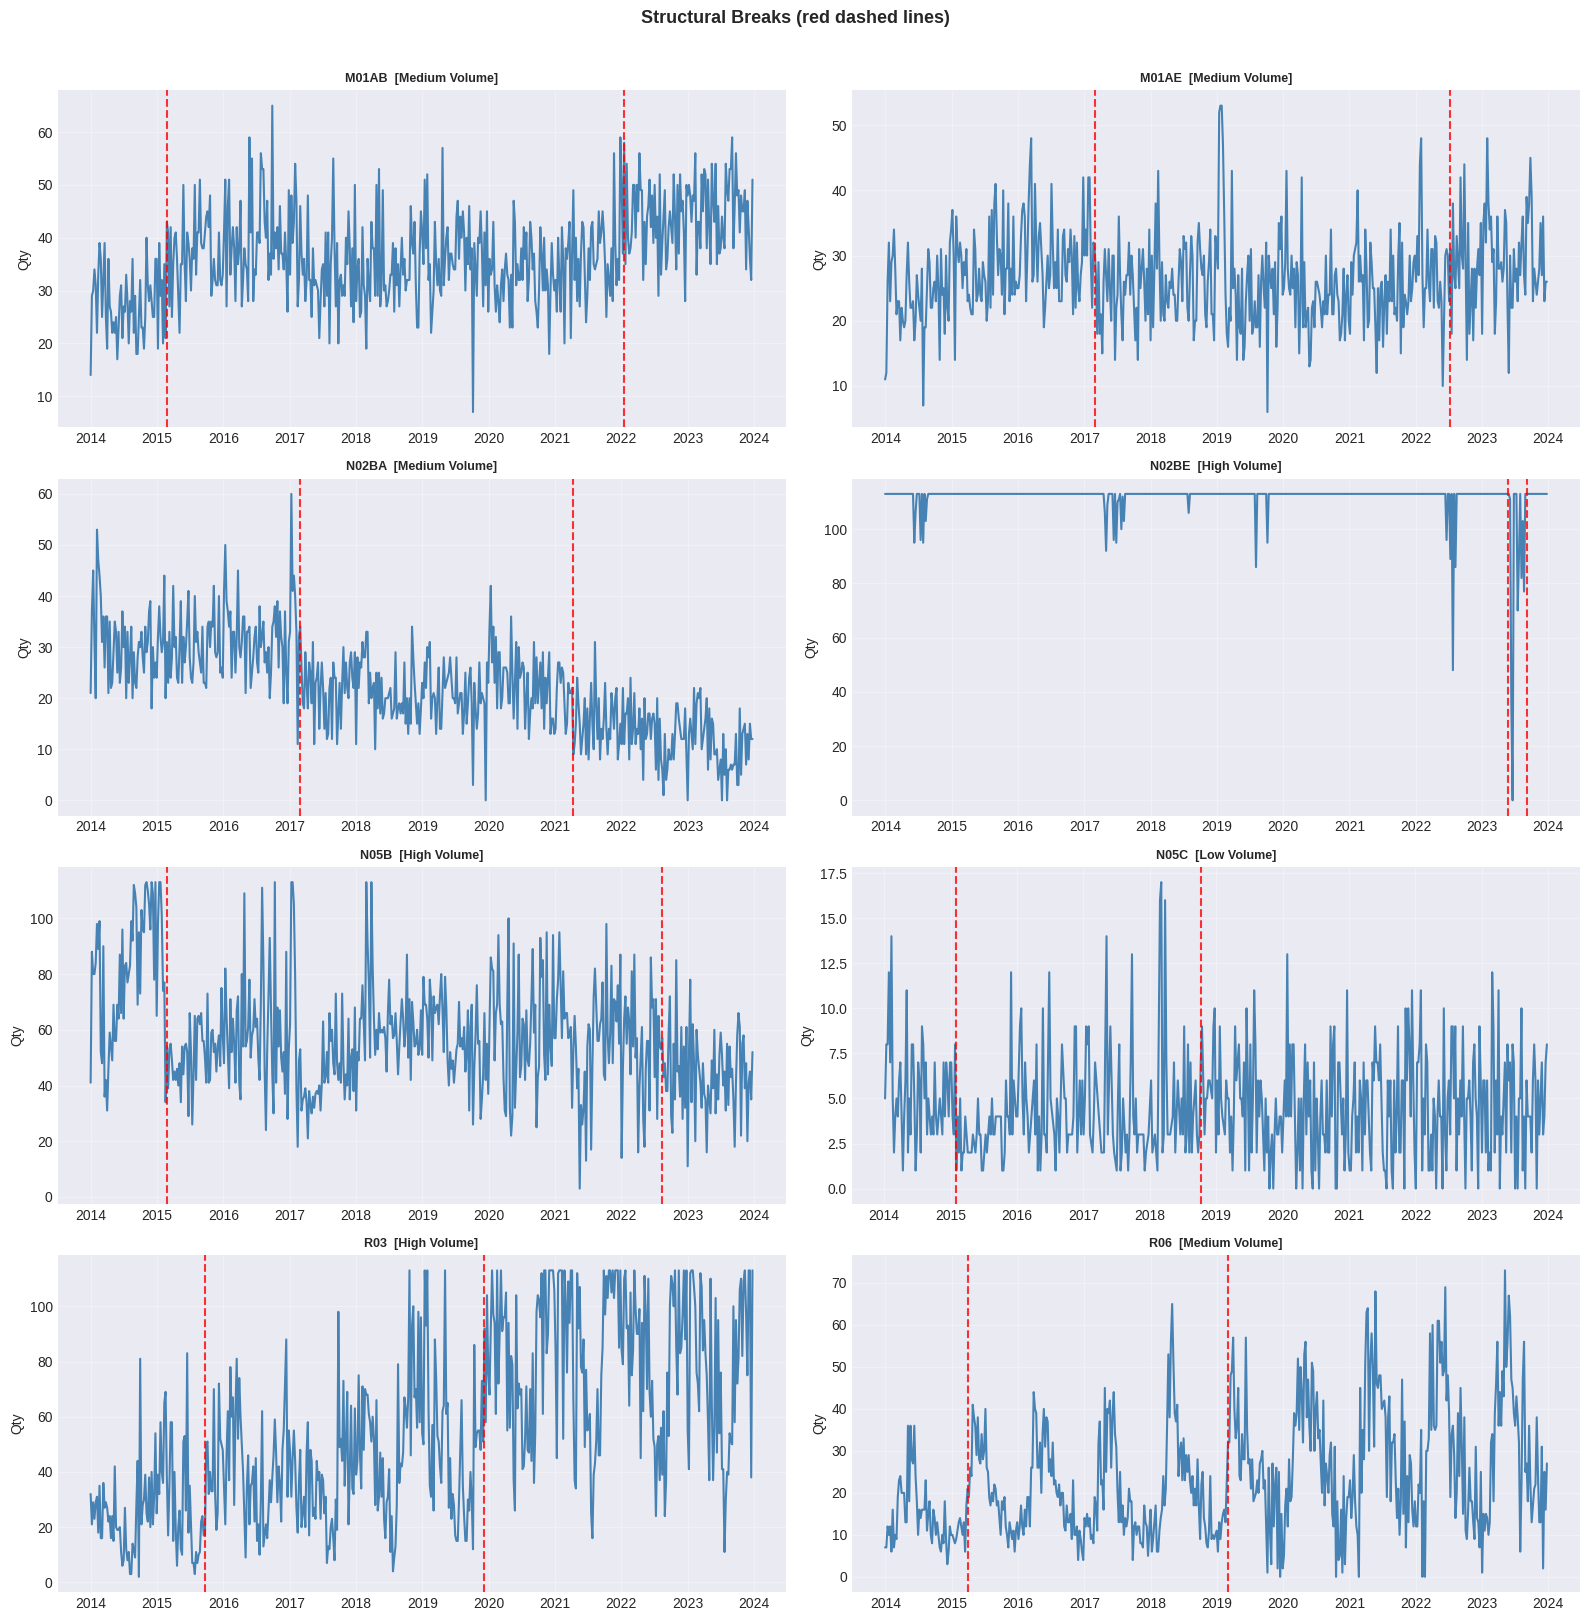


=== BREAK SUMMARY ===
✓  M01AB                           last_break=2022-01-17 00:00:00  weeks_after=102
✓  M01AE                           last_break=2022-07-11 00:00:00  weeks_after=77
✓  N02BA                           last_break=2021-04-12 00:00:00  weeks_after=142
⚠ SHORT  N02BE                           last_break=2023-09-04 00:00:00  weeks_after=17
✓  N05B                            last_break=2022-08-15 00:00:00  weeks_after=72
✓  N05C                            last_break=2018-10-08 00:00:00  weeks_after=271
✓  R03                             last_break=2019-12-09 00:00:00  weeks_after=212
✓  R06                             last_break=2019-03-04 00:00:00  weeks_after=252


In [5]:
def detect_breaks(series, n_bkps=2):
    """Returns list of breakpoint positions in the series."""
    if RUPTURES_AVAILABLE and len(series) > 2 * n_bkps + 2:
        algo = Binseg(model='rbf').fit(series.values.reshape(-1, 1))
        bkps = algo.predict(n_bkps=n_bkps)
        return bkps[:-1]
    # Fallback: largest rolling-mean jump
    roll = pd.Series(series.values).rolling(8, min_periods=1).mean()
    diffs = roll.diff().abs().fillna(0)
    bkp = int(diffs.idxmax()) if len(diffs) > 0 else 0
    return [bkp]

break_info = {}

n = len(selected_drugs)
ncols = 2
nrows = max(1, (n + 1) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten() if n > 1 else [axes]

for i, drug in enumerate(selected_drugs):
    s = (train_df[train_df['drug_name'] == drug]
         .sort_values('week_start_date')
         .set_index('week_start_date')['total_quantity'])

    try:
        bkps = detect_breaks(s)
        last  = bkps[-1] if bkps else 0
    except Exception:
        bkps, last = [], 0

    break_info[drug] = {
        'all_breaks'      : bkps,
        'last_break_idx'  : last,
        'last_break_date' : s.index[last] if last < len(s) else None,
        'weeks_after_break': len(s) - last
    }

    ax = axes[i]
    ax.plot(s.index, s.values, linewidth=1.5, color='steelblue')
    for b in bkps:
        if b < len(s):
            ax.axvline(s.index[b], color='red', linestyle='--', alpha=0.8, linewidth=1.5)
    ax.set_title(f'{drug}  [{seg_map.get(drug)}]', fontsize=9, fontweight='bold')
    ax.set_ylabel('Qty'); ax.grid(True, alpha=0.3)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Structural Breaks (red dashed lines)', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

print('\n=== BREAK SUMMARY ===')
for drug, info in break_info.items():
    flag = '⚠ SHORT' if info['weeks_after_break'] < 52 else '✓'
    print(f'{flag}  {drug:30s}  last_break={info["last_break_date"]}  '
          f'weeks_after={info["weeks_after_break"]}')

## 4. STATIONARITY TESTING

Determines the differencing order `d` for each drug.

In [6]:
def test_stationarity(series, drug_name):
    s = series.dropna()
    if len(s) < 20:
        return {'drug': drug_name, 'adf_p': None, 'kpss_p': None,
                'verdict': 'Insufficient data', 'd_recommended': 1}

    adf_stat, adf_p = adfuller(s, autolag='AIC')[:2]
    try:
        kpss_stat, kpss_p = kpss(s, regression='c', nlags='auto')[:2]
    except Exception:
        kpss_p = 0.0

    adf_ok  = adf_p  < 0.05
    kpss_ok = kpss_p > 0.05

    if adf_ok and kpss_ok:
        verdict, d = 'Stationary', 0
    elif adf_ok:
        verdict, d = 'Likely Stationary', 0
    else:
        verdict, d = 'Non-Stationary', 1

    return {'drug': drug_name, 'adf_p': round(adf_p, 4), 'kpss_p': round(kpss_p, 4),
            'verdict': verdict, 'd_recommended': d}

stat_results = []
for drug in selected_drugs:
    info = break_info[drug]
    s = (train_df[train_df['drug_name'] == drug]
         .sort_values('week_start_date')['total_quantity']
         .iloc[info['last_break_idx']:])
    if len(s) < 20:
        s = train_df[train_df['drug_name'] == drug].sort_values('week_start_date')['total_quantity']
    stat_results.append(test_stationarity(s, drug))

stat_df = pd.DataFrame(stat_results)
print('=== STATIONARITY RESULTS ===')
display(stat_df)
print(f"\nStationary     : {(stat_df['verdict']=='Stationary').sum()} drugs  → d=0")
print(f"Likely Stat.   : {(stat_df['verdict']=='Likely Stationary').sum()} drugs")
print(f"Non-Stationary : {(stat_df['verdict']=='Non-Stationary').sum()} drugs  → d=1")

=== STATIONARITY RESULTS ===


,drug,adf_p,kpss_p,verdict,d_recommended
0,M01AB,0.0000,0.1000,Stationary,0
1,M01AE,0.0022,0.1000,Stationary,0
2,N02BA,0.0151,0.0100,Likely Stationary,0
3,N02BE,0.0000,0.0714,Stationary,0
4,N05B,0.0000,0.1000,Stationary,0
5,N05C,0.0000,0.1000,Stationary,0
6,R03,0.0003,0.1000,Stationary,0
7,R06,0.0000,0.1000,Stationary,0



Stationary     : 7 drugs  → d=0
Likely Stat.   : 1 drugs
Non-Stationary : 0 drugs  → d=1


## 5. EVALUATION METRICS

**WMAPE** is the primary metric — it is volume-weighted so low-volume drugs don't dominate the average.

In [7]:
def calculate_metrics(y_true, y_pred, model_name='SARIMA', drug=None, segment=None):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.clip(np.array(y_pred, dtype=float), 0, None)   # no negative forecasts

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    # MAPE only on rows where actual > 5 (avoids inflation by tiny values)
    mask = y_true > 5
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan

    # WMAPE — primary metric
    wmape = np.sum(np.abs(y_true - y_pred)) / np.sum(y_true) * 100 if np.sum(y_true) > 0 else np.nan

    return {
        'Model'  : model_name,
        'Drug'   : drug,
        'Segment': segment,
        'MAE'    : round(mae,  2),
        'RMSE'   : round(rmse, 2),
        'MAPE'   : round(mape, 2) if not np.isnan(mape) else None,
        'WMAPE'  : round(wmape, 2) if not np.isnan(wmape) else None,
        'R2'     : round(r2,   4)
    }

print('✓ Metrics helper ready')
print('  Primary : WMAPE  (volume-weighted, robust to low-volume drugs)')
print('  MAPE    : computed only where actual > 5')

✓ Metrics helper ready
  Primary : WMAPE  (volume-weighted, robust to low-volume drugs)
  MAPE    : computed only where actual > 5


## 6. SARIMA PARAMETER SELECTION

In [8]:
import json
from pathlib import Path

# ── Cache directories ─────────────────────────────────────────────────────────
CACHE_DIR    = Path(project_root) / 'models' / 'checkpoints'
ORDERS_CACHE = CACHE_DIR / 'sarima_orders.json'
MODELS_CACHE = CACHE_DIR / 'sarima_fitted.pkl'
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Load previously saved orders (avoids re-running auto_arima)
try:
    with open(ORDERS_CACHE) as f:
        _saved_orders = json.load(f)
    print(f'✓ Loaded cached orders for {list(_saved_orders.keys())}')
except FileNotFoundError:
    _saved_orders = {}
    print('  No cached orders found — will run auto_arima (first time only)')

def get_sarima_order(series, drug_name, seasonal_period=52):
    """Best (p,d,q)(P,D,Q,s) via auto_arima or manual grid search, cached to disk."""
    # ── Use cached order if available ─────────────────────────────────────────
    if drug_name in _saved_orders:
        cached  = _saved_orders[drug_name]
        order   = tuple(cached['order'])
        s_order = tuple(cached['s_order'])
        aic     = cached['aic']
        print(f'  (cached order, skipping auto_arima)')
        return order, s_order, aic, 'cached'

    s = series.dropna()
    d_rec = stat_df.loc[stat_df['drug'] == drug_name, 'd_recommended']
    d = int(d_rec.values[0]) if len(d_rec) > 0 else 1

    if AUTO_ARIMA_AVAILABLE:
        try:
            mdl = auto_arima(
                s, d=d,
                # FIX 2b: start at p=1,q=1 so auto_arima never selects the null
                # model (0,0,0) which has zero parameters and crashes L-BFGS-B.
                start_p=1, max_p=2, start_q=1, max_q=2,
                seasonal=True, m=seasonal_period,
                start_P=0, max_P=0,
                # FIX 2b: allow Q=1 so the seasonal part can be (0,1,1,52)
                # instead of the null (0,1,0,52).
                start_Q=0, max_Q=1,
                D=1,
                information_criterion='aic', stepwise=True,
                suppress_warnings=True, error_action='ignore',
                n_fits=10
            )
            order, s_order, aic = mdl.order, mdl.seasonal_order, mdl.aic()
            method = 'auto_arima'
        except Exception as e:
            print(f'  auto_arima failed ({e}) — falling back to grid')
            order, s_order, aic, method = _manual_grid(s, d, seasonal_period)
    else:
        order, s_order, aic, method = _manual_grid(s, d, seasonal_period)

    # ── Persist order so next run skips search ─────────────────────────────────
    _saved_orders[drug_name] = {'order': list(order), 's_order': list(s_order), 'aic': aic}
    with open(ORDERS_CACHE, 'w') as f:
        json.dump(_saved_orders, f, indent=2)

    return order, s_order, aic, method


def _manual_grid(s, d, seasonal_period):
    """Grid search (p,q ∈ {1,2}) with (0,1,1,s) seasonal — avoids null models."""
    best_aic, best_order, best_s_order = np.inf, (1, d, 1), (0, 1, 1, seasonal_period)
    for p in range(1, 3):
        for q in range(1, 3):
            for Q in [0, 1]:
                s_ord = (0, 1, Q, seasonal_period)
                try:
                    r = SARIMAX(s, order=(p, d, q),
                                seasonal_order=s_ord,
                                simple_differencing=True,
                                enforce_stationarity=False,
                                enforce_invertibility=False).fit(
                                    disp=False, maxiter=100, method='powell')
                    if r.aic < best_aic:
                        best_aic     = r.aic
                        best_order   = (p, d, q)
                        best_s_order = s_ord
                except Exception:
                    continue
    return best_order, best_s_order, best_aic, 'grid_search'


print('✓ Parameter selection ready  (with disk caching)')
print('  Seasonal period : m=52  (annual — weekly data)')
print('  auto_arima      : start_p=1, start_q=1, max_Q=1 — prevents null models')
print(f'  Orders cache    : {ORDERS_CACHE}')
print(f'  Models cache    : {MODELS_CACHE}')


✓ Loaded cached orders for ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
✓ Parameter selection ready  (with disk caching)
  Seasonal period : m=52  (annual — weekly data)
  auto_arima      : start_p=1, start_q=1, max_Q=1 — prevents null models
  Orders cache    : /home/brenda/final year project/PharmacyForecastingSystem/models/checkpoints/sarima_orders.json
  Models cache    : /home/brenda/final year project/PharmacyForecastingSystem/models/checkpoints/sarima_fitted.pkl


In [17]:
# Run this once to clear stale cached orders so the new (0,1,0,52) seasonal
# config is used.  Re-comment after the first successful run.
import shutil
from pathlib import Path

_cache_dir = Path(project_root) / 'models' / 'checkpoints'
for fname in ['sarima_orders.json', 'sarima_fitted.pkl']:
    p = _cache_dir / fname
    if p.exists():
        p.unlink()
        print(f'✓ Cleared cache: {p}')
    else:
        print(f'  (not found, nothing to clear): {p}')
print('Cache cleared — re-run the cells below to retrain with new settings.')


  (not found, nothing to clear): /home/brenda/final year project/PharmacyForecastingSystem/models/checkpoints/sarima_orders.json
✓ Cleared cache: /home/brenda/final year project/PharmacyForecastingSystem/models/checkpoints/sarima_fitted.pkl
Cache cleared — re-run the cells below to retrain with new settings.


In [18]:
for drug in selected_drugs:
    s = train_df[train_df['drug_name'] == drug]['total_quantity']
    print(f"{drug}: dtype={s.dtype}, nulls={s.isnull().sum()}, "
          f"non-numeric={(pd.to_numeric(s, errors='coerce').isnull().sum())}")

M01AB: dtype=int64, nulls=0, non-numeric=0
M01AE: dtype=int64, nulls=0, non-numeric=0
N02BA: dtype=int64, nulls=0, non-numeric=0
N02BE: dtype=int64, nulls=0, non-numeric=0
N05B: dtype=int64, nulls=0, non-numeric=0
N05C: dtype=int64, nulls=0, non-numeric=0
R03: dtype=int64, nulls=0, non-numeric=0
R06: dtype=int64, nulls=0, non-numeric=0


In [19]:
import os
from pathlib import Path

cache_dir = Path(project_root) / 'models' / 'checkpoints'

for f in ['sarima_orders.json', 'sarima_fitted.pkl']:
    p = cache_dir / f
    if p.exists():
        os.remove(p)
        print(f'✓ Deleted {f}')
    else:
        print(f'  {f} not found — skipping')

  sarima_orders.json not found — skipping
  sarima_fitted.pkl not found — skipping


## 7. FIT SARIMA PER DRUG

In [20]:
import time, os

# ── FORCE DELETE BOTH CACHES EVERY TIME THIS CELL RUNS ───────────────────────
# The fitted.pkl contains models trained on a broken index. We must always
# delete it here so we never load a stale model.
for _p in [ORDERS_CACHE, MODELS_CACHE]:
    if _p.exists():
        _p.unlink()
        print(f'✓ Cleared: {_p.name}')
_saved_orders.clear()   # also wipe the in-memory dict from Cell 14
print('Caches cleared — fitting fresh\n')

sarima_results = {}
fitted_models  = {}
param_log      = []
MIN_WEEKS      = 52
HORIZON        = 4


def _fit_model(mdl):
    """lbfgs → powell → nm fallback."""
    for method in ['lbfgs', 'powell', 'nm']:
        try:
            return mdl.fit(disp=False, maxiter=100, method=method)
        except (ValueError, np.linalg.LinAlgError):
            if method == 'nm':
                raise
            continue


def _make_series(df, drug):
    """
    Return a clean float64 Series with a plain RangeIndex (integer positions).
    
    WHY RANGEINDEX: Every approach using DatetimeIndex or PeriodIndex with
    extend() fails because statsmodels internally calls
        pd.date_range(start=self._index[0], ...)
    on the fitted model's index.  When the index type fed to SARIMAX at fit
    time differs from what extend() receives, self._index ends up empty and
    crashes with 'index 0 is out of bounds for axis 0 with size 0'.
    
    A plain RangeIndex bypasses all date/period inference in statsmodels
    completely.  SARIMAX treats it as a simple integer-indexed series, fits
    and forecasts correctly, and extend() never tries to build a DatetimeIndex
    at all.  We keep the original DatetimeIndex separately for plotting.
    """
    s = (df[df['drug_name'] == drug]
         .sort_values('week_start_date')
         .set_index('week_start_date')['total_quantity']
         .astype(np.float64))
    dates = s.index.copy()                        # save for plotting
    s_plain = pd.Series(s.values, dtype=np.float64)   # RangeIndex 0,1,2,...
    return s_plain, dates


def rolling_forecast(fitted_model, test_values, horizon=4):
    """
    Walk-forward forecast using get_forecast() + apply() to update state.
    apply() is used instead of extend() — it is more robust to index type
    mismatches because it re-runs the Kalman filter on the full concatenated
    series rather than trying to clone and extend the existing model object.
    """
    preds       = []
    n_train     = len(fitted_model.model.endog)
    full_endog  = list(fitted_model.model.endog.flatten())

    for start in range(0, len(test_values), horizon):
        window = test_values[start : start + horizon]
        if len(window) == 0:
            break

        # Forecast from current end of known data
        try:
            fc = fitted_model.apply(
                pd.Series(full_endog, dtype=np.float64)
            ).get_forecast(steps=len(window))
            preds.extend(np.clip(fc.predicted_mean.values, 0, None))
        except Exception:
            # Last resort: repeat last fitted value
            fallback = float(fitted_model.fittedvalues[-1]) if len(fitted_model.fittedvalues) > 0 else 0.0
            preds.extend([max(0.0, fallback)] * len(window))

        # Reveal actuals and append to known history
        full_endog.extend(window.tolist())

    return np.array(preds[:len(test_values)])


# ── Sample date printout ──────────────────────────────────────────────────────
sample_date = train_df['week_start_date'].iloc[0]
print(f'Week start day: {sample_date.day_name()} ({sample_date.date()})')
print(f'Using plain RangeIndex — no DatetimeIndex passed to SARIMAX\n')

t_total = time.time()
for i, drug in enumerate(selected_drugs):
    t0 = time.time()
    print(f'\n[{i+1}/{len(selected_drugs)}]  {drug}  [{seg_map.get(drug)}]')
    info    = break_info[drug]
    segment = seg_map.get(drug, 'Unknown')

    # Build plain-indexed series (no DatetimeIndex → no extend() crash)
    train_plain, train_dates = _make_series(train_df, drug)
    post_break = train_plain.iloc[info['last_break_idx']:]
    fit_s      = post_break.reset_index(drop=True) if len(post_break) >= MIN_WEEKS else train_plain
    note = f'post-break ({len(fit_s)}w)' if len(post_break) >= MIN_WEEKS else f'full series ({len(fit_s)}w)'
    print(f'  Training : {note}')

    test_plain, test_dates = _make_series(test_df, drug)

    try:
        order, s_order, aic, method = get_sarima_order(fit_s, drug)

        # Guard against null model
        if order == (0, 0, 0) and s_order[0] == 0 and s_order[2] == 0:
            print(f'  ⚠ Null model → overriding to (1,0,1)(0,1,1,{s_order[3]})')
            order   = (1, 0, 1)
            s_order = (0, 1, 1, s_order[3])

        print(f'  Order={order}  Seasonal={s_order}  AIC={aic:.1f}  method={method}')

        mdl = SARIMAX(fit_s, order=order, seasonal_order=s_order,
                      simple_differencing=True,
                      enforce_stationarity=False,
                      enforce_invertibility=False)
        fitted = _fit_model(mdl)

        # Rolling forecast on plain numpy values
        pred = rolling_forecast(fitted, test_plain.values, horizon=HORIZON)
        print(f'  Rolling forecast: {len(test_plain)} weeks in {HORIZON}-week windows')

        lb_p = acorr_ljungbox(fitted.resid, lags=[10], return_df=True)['lb_pvalue'].values[0]

        metrics = calculate_metrics(test_plain.values, pred, drug=drug, segment=segment)
        metrics.update({'AIC': round(fitted.aic, 2), 'LB_p': round(lb_p, 4),
                        'LB_ok': lb_p > 0.05, 'order': str(order),
                        's_order': str(s_order), 'n_train': len(fit_s), 'n_test': len(test_plain)})

        try:
            ci = fitted.get_forecast(steps=min(HORIZON, len(test_plain))).conf_int()
        except Exception:
            ci = None

        sarima_results[drug] = {
            'predictions': pred, 'actuals': test_plain.values,
            'dates': test_dates,           # original DatetimeIndex for plotting
            'conf_int': ci,
            'train_series': pd.Series(fit_s.values, index=train_dates[info['last_break_idx']:] 
                                      if len(post_break) >= MIN_WEEKS else train_dates),
            'metrics': metrics
        }
        fitted_models[drug] = fitted
        param_log.append(metrics)

        beat    = '✅ BEATS baseline' if metrics['MAE'] < BASELINE_MAE else '❌ below baseline'
        lb_note = '✓ white noise'    if lb_p > 0.05 else '⚠ autocorrelated'
        elapsed = time.time() - t0
        print(f'  MAE={metrics["MAE"]} | WMAPE={metrics["WMAPE"]}% | R²={metrics["R2"]}  {beat}')
        print(f'  LB p={lb_p:.4f} → residuals {lb_note}  [{elapsed:.1f}s]')

    except Exception as e:
        print(f'  ❌ FAILED: {e}')
        import traceback; traceback.print_exc()
        param_log.append({'Model':'SARIMA','Drug':drug,'Segment':segment,
                          'MAE':None,'RMSE':None,'MAPE':None,'WMAPE':None,'R2':None,
                          'AIC':None,'LB_p':None,'LB_ok':None,'order':'FAILED',
                          's_order':'FAILED','n_train':0,'n_test':0})

results_df = pd.DataFrame(param_log)
print(f'\n✓ SARIMA fitted for {len(sarima_results)}/{len(selected_drugs)} drugs')
print(f'  Total time: {time.time()-t_total:.1f}s')

Caches cleared — fitting fresh

Week start day: Monday (2013-12-30)
Using plain RangeIndex — no DatetimeIndex passed to SARIMAX


[1/8]  M01AB  [Medium Volume]
  Training : post-break (102w)
  ⚠ Null model → overriding to (1,0,1)(0,1,1,52)
  Order=(1, 0, 1)  Seasonal=(0, 1, 1, 52)  AIC=365.4  method=auto_arima
  Rolling forecast: 104 weeks in 4-week windows
  MAE=44.18 | WMAPE=90.78% | R²=-24.6719  ❌ below baseline
  LB p=0.0000 → residuals ⚠ autocorrelated  [25.7s]

[2/8]  M01AE  [Medium Volume]
  Training : post-break (77w)
  ⚠ Null model → overriding to (1,0,1)(0,1,1,52)
  Order=(1, 0, 1)  Seasonal=(0, 1, 1, 52)  AIC=164.0  method=auto_arima
  Rolling forecast: 104 weeks in 4-week windows
  MAE=49.95 | WMAPE=159.21% | R²=-161.7525  ❌ below baseline
  LB p=0.0000 → residuals ⚠ autocorrelated  [4.9s]

[3/8]  N02BA  [Medium Volume]
  Training : post-break (142w)
  Order=(0, 0, 0)  Seasonal=(0, 1, 1, 52)  AIC=602.6  method=auto_arima
  Rolling forecast: 104 weeks in 4-week windows
  MAE

## 8. RESULTS TABLE

In [21]:
print('=== SARIMA RESULTS — ALL DRUGS ===')
cols = ['Drug','Segment','MAE','RMSE','WMAPE','MAPE','R2','AIC','LB_ok','order','s_order','n_train']
display(results_df[cols].sort_values('WMAPE'))

=== SARIMA RESULTS — ALL DRUGS ===


,Drug,Segment,MAE,RMSE,WMAPE,MAPE,R2,AIC,LB_ok,order,s_order,n_train
0,M01AB,Medium Volume,44.1800,45.7400,90.7800,90.1100,-24.6719,8.0000,False,"(1, 0, 1)","(0, 1, 1, 52)",102
5,N05C,Low Volume,3.6500,4.4400,91.8800,94.1100,-2.1505,887.6800,True,"(1, 0, 1)","(0, 1, 1, 52)",271
3,N02BE,High Volume,104.4200,106.0200,95.2700,95.1600,-55.4101,2926.0100,False,"(2, 0, 2)","(0, 1, 1, 52)",522
7,R06,Medium Volume,31.7800,35.9300,96.3600,95.4800,-3.5765,1595.7600,True,"(2, 0, 0)","(0, 1, 0, 52)",252
2,N02BA,Medium Volume,6.4700,8.4000,100.0000,100.0000,-1.4634,251.9600,True,"(0, 0, 0)","(0, 1, 1, 52)",142
6,R03,High Volume,78.0100,82.7300,100.0000,100.0000,-8.0270,4813.0400,True,"(0, 0, 0)","(0, 1, 1, 52)",212
1,M01AE,Medium Volume,49.9500,77.1400,159.2100,158.8400,-161.7525,8.0000,False,"(1, 0, 1)","(0, 1, 1, 52)",77
4,N05B,High Volume,148.4700,376.1300,434.3300,393.6700,-584.6460,8.0000,True,"(1, 0, 1)","(0, 1, 1, 52)",72


## 9. SEGMENT-LEVEL COMPARISON WITH BASELINE

In [22]:
valid = results_df.dropna(subset=['MAE'])

print('=== SARIMA BY SEGMENT ===')
seg_summary = valid.groupby('Segment')[['MAE','RMSE','WMAPE','MAPE','R2']].mean().round(3)
display(seg_summary)

print('\n=== OVERALL: SARIMA vs HOLT-WINTERS BASELINE ===')
sarima_avg = valid[['MAE','RMSE','WMAPE','MAPE','R2']].mean()
comparison = pd.DataFrame({
    'Holt-Winters Baseline': [BASELINE_MAE, BASELINE_RMSE, '—', BASELINE_MAPE, BASELINE_R2],
    'SARIMA (avg)'         : [round(sarima_avg['MAE'],2), round(sarima_avg['RMSE'],2),
                               round(sarima_avg['WMAPE'],2), round(sarima_avg['MAPE'],2),
                               round(sarima_avg['R2'],4)]
}, index=['MAE','RMSE','WMAPE','MAPE','R2'])
display(comparison)

n_beat = (valid['MAE'] < BASELINE_MAE).sum()
print(f'\nSARIMA beats baseline for {n_beat}/{len(valid)} drugs')

=== SARIMA BY SEGMENT ===


,MAE,RMSE,WMAPE,MAPE,R2
Segment,,,,,
High Volume,110.3000,188.2930,209.8670,196.2770,-216.0280
Low Volume,3.6500,4.4400,91.8800,94.1100,-2.1500
Medium Volume,33.0950,41.8020,111.5880,111.1080,-47.8660



=== OVERALL: SARIMA vs HOLT-WINTERS BASELINE ===


,Holt-Winters Baseline,SARIMA (avg)
MAE,7.7541,58.3700
RMSE,10.5458,92.0700
WMAPE,—,145.9800
MAPE,inf,140.9200
R2,0.0958,-105.2122



SARIMA beats baseline for 2/8 drugs


## 10. RESIDUAL DIAGNOSTICS (Best & Worst Drug)

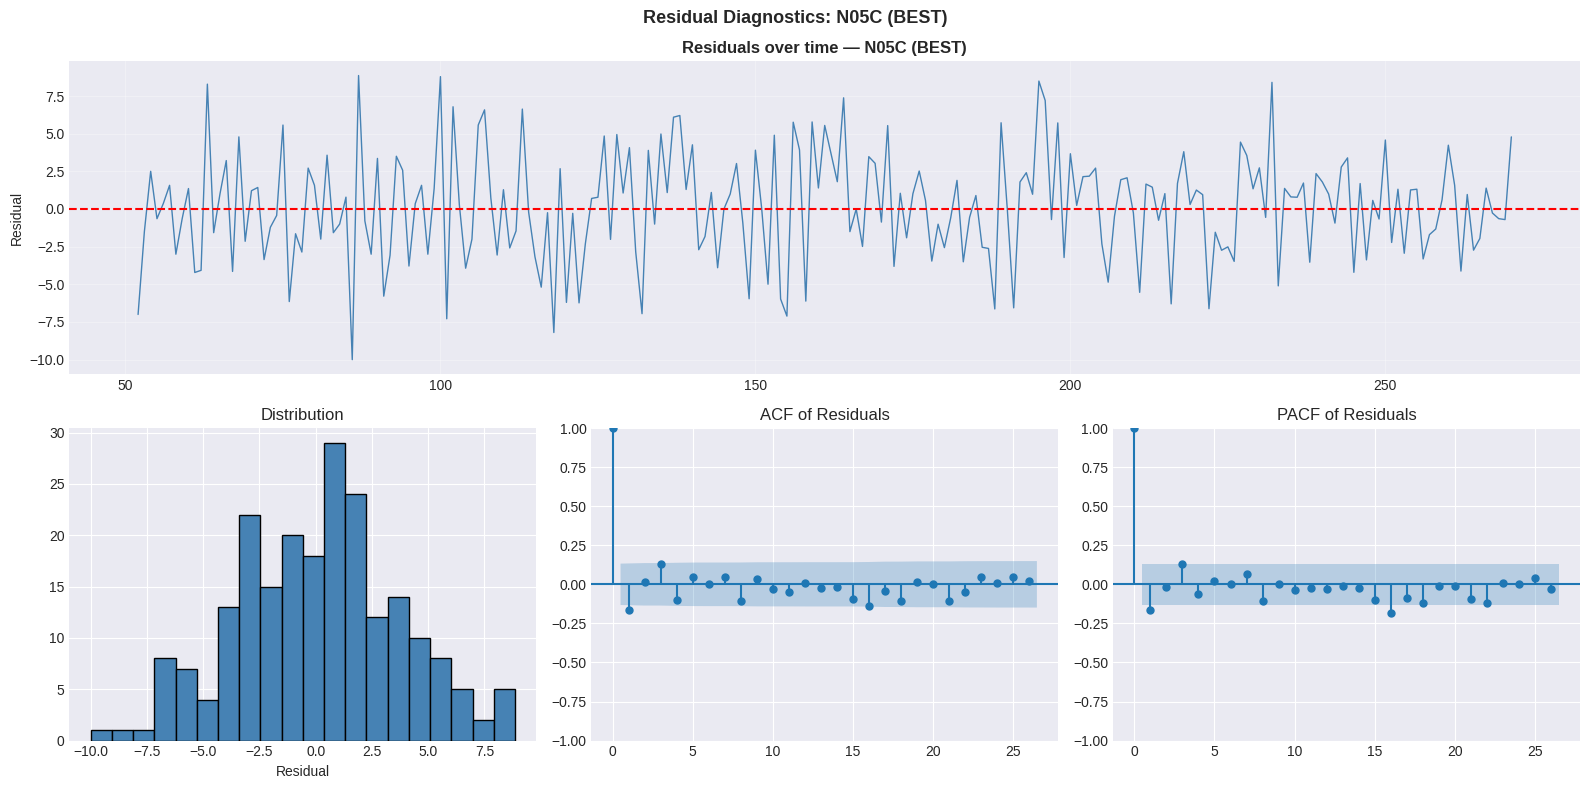

N05C: LB p=0.1133 -> White noise ✓


ValueError: could not broadcast input array from shape (20,) into shape (27,)

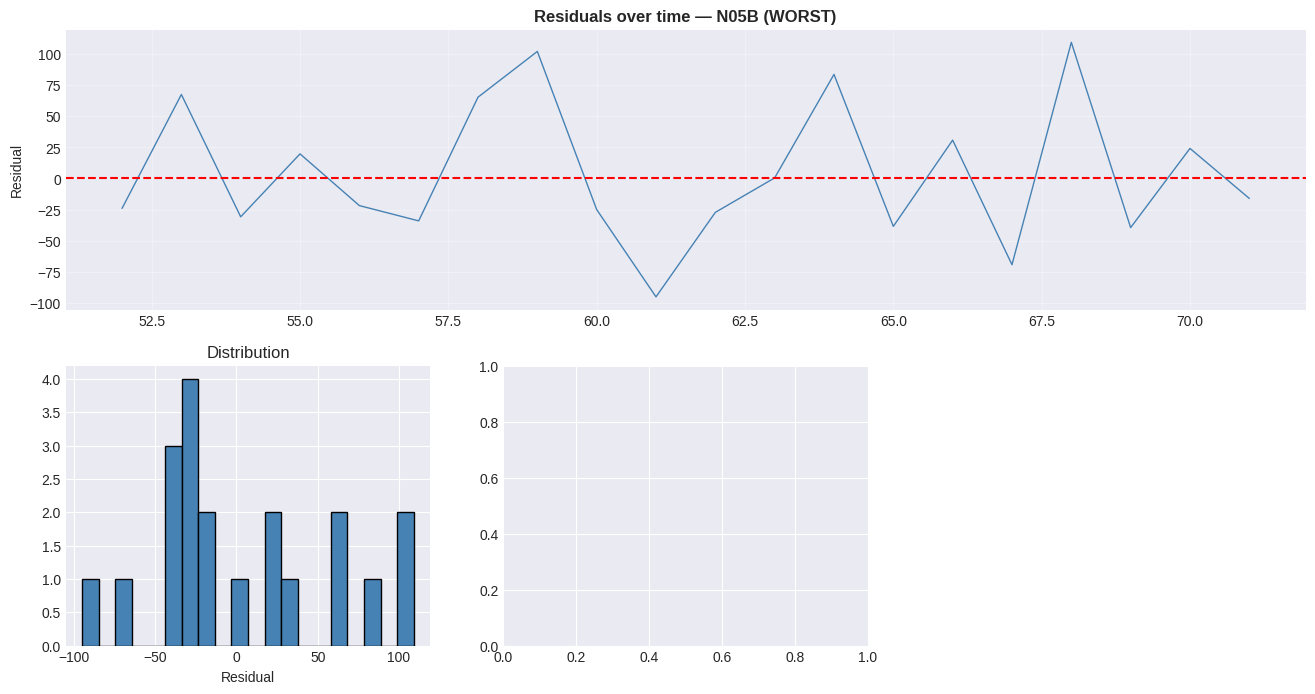

In [ ]:
valid_sorted = results_df.dropna(subset=['MAE']).sort_values('MAE')
show = [(valid_sorted.iloc[0]['Drug'], 'BEST'), (valid_sorted.iloc[-1]['Drug'], 'WORST')]

for drug, label in show:
    if drug not in fitted_models:
        continue
    resid = fitted_models[drug].resid
    resid_clean = resid.dropna()
    n_obs = len(resid_clean)

    fig = plt.figure(figsize=(16, 8))
    gs  = gridspec.GridSpec(2, 3, figure=fig)

    ax0 = fig.add_subplot(gs[0, :])
    ax0.plot(resid.index, resid.values, linewidth=1, color='steelblue')
    ax0.axhline(0, color='red', linestyle='--')
    ax0.set_title(f'Residuals over time — {drug} ({label})', fontweight='bold')
    ax0.set_ylabel('Residual'); ax0.grid(True, alpha=0.3)

    ax1 = fig.add_subplot(gs[1, 0])
    resid_clean.hist(bins=20, ax=ax1, edgecolor='black', color='steelblue')
    ax1.set_title('Distribution'); ax1.set_xlabel('Residual')

    ax2 = fig.add_subplot(gs[1, 1])
    if n_obs >= 3:
        acf_lags = min(26, n_obs - 1)
        plot_acf(resid_clean, lags=acf_lags, ax=ax2)
        ax2.set_title(f'ACF of Residuals (lags={acf_lags})')
    else:
        ax2.text(0.5, 0.5, 'Not enough residuals for ACF', ha='center', va='center')
        ax2.set_title('ACF of Residuals')

    ax3 = fig.add_subplot(gs[1, 2])
    if n_obs >= 4:
        pacf_lags = min(26, (n_obs // 2) - 1)
        pacf_lags = max(1, pacf_lags)
        plot_pacf(resid_clean, lags=pacf_lags, ax=ax3, method='ywm')
        ax3.set_title(f'PACF of Residuals (lags={pacf_lags})')
    else:
        ax3.text(0.5, 0.5, 'Not enough residuals for PACF', ha='center', va='center')
        ax3.set_title('PACF of Residuals')

    plt.suptitle(f'Residual Diagnostics: {drug} ({label})', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()

    lb_p = results_df.loc[results_df['Drug'] == drug, 'LB_p'].values[0]
    print(f'{drug}: LB p={lb_p:.4f} -> {"White noise ✓" if lb_p > 0.05 else "Autocorrelated ⚠ — try higher p/q"}')

## 11. FORECAST VISUALISATION

In [ ]:
n     = len(sarima_results)
ncols = 2
nrows = max(1, (n + 1) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes = axes.flatten() if n > 1 else [axes]

for idx, (drug, res) in enumerate(sarima_results.items()):
    ax = axes[idx]
    train_plot = res['train_series'].iloc[-52:]   # last year of training only

    ax.plot(train_plot.index, train_plot.values,
            color='steelblue', linewidth=1.5, alpha=0.7, label='Train (last 52w)')
    ax.plot(res['dates'], res['actuals'],
            color='black', linewidth=2, marker='o', markersize=4, label='Actual')
    ax.plot(res['dates'], res['predictions'],
            color='red', linewidth=2, linestyle='--', marker='s', markersize=4, label='SARIMA')

    ci = res['conf_int']
    if ci is not None:
        ax.fill_between(res['dates'],
                        np.clip(ci.iloc[:,0].values, 0, None),
                        ci.iloc[:,1].values,
                        alpha=0.15, color='red', label='95% CI')

    m = res['metrics']
    ax.set_title(f"{drug}  [{seg_map.get(drug)}]\nMAE={m['MAE']} | WMAPE={m['WMAPE']}% | R²={m['R2']}",
                 fontsize=9, fontweight='bold')
    ax.axvline(res['dates'][0], color='gray', linestyle=':', linewidth=1.5)
    ax.set_ylabel('Qty'); ax.grid(True, alpha=0.3); ax.legend(fontsize=7)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('SARIMA Forecasts vs Actuals  (red dashed = train/test split)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 12. PERFORMANCE DASHBOARD

In [ ]:
valid     = results_df.dropna(subset=['MAE']).sort_values('MAE')
colors_s  = {'Low Volume':'salmon','Medium Volume':'gold','High Volume':'steelblue','Unknown':'gray'}
bar_clr   = [colors_s.get(s,'gray') for s in valid['Segment']]

fig, axes = plt.subplots(2, 2, figsize=(16, 11))

# MAE per drug
axes[0,0].barh(valid['Drug'], valid['MAE'], color=bar_clr, edgecolor='black')
axes[0,0].axvline(BASELINE_MAE, color='red', linestyle='--', linewidth=2, label=f'Baseline {BASELINE_MAE}')
axes[0,0].set_title('MAE per Drug (lower is better)', fontweight='bold')
axes[0,0].set_xlabel('MAE'); axes[0,0].legend()

# WMAPE per drug
w_sorted = valid.sort_values('WMAPE')
axes[0,1].barh(w_sorted['Drug'], w_sorted['WMAPE'],
               color=[colors_s.get(s,'gray') for s in w_sorted['Segment']], edgecolor='black')
axes[0,1].set_title('WMAPE per Drug — PRIMARY METRIC', fontweight='bold')
axes[0,1].set_xlabel('WMAPE %')

# R² per drug
r_sorted = valid.sort_values('R2', ascending=False)
r_clr    = ['steelblue' if v >= 0 else 'salmon' for v in r_sorted['R2']]
axes[1,0].barh(r_sorted['Drug'], r_sorted['R2'], color=r_clr, edgecolor='black')
axes[1,0].axvline(0,             color='black', linestyle='-',  linewidth=1)
axes[1,0].axvline(BASELINE_R2,   color='red',   linestyle='--', linewidth=2, label=f'Baseline R²={BASELINE_R2}')
axes[1,0].set_title('R² per Drug (higher / less negative is better)', fontweight='bold')
axes[1,0].set_xlabel('R²'); axes[1,0].legend()

# Segment avg
if len(seg_summary) > 0:
    seg_summary[['MAE','WMAPE']].plot(kind='bar', ax=axes[1,1], edgecolor='black')
    axes[1,1].set_title('Avg MAE & WMAPE by Volume Segment', fontweight='bold')
    axes[1,1].set_xlabel('Segment'); axes[1,1].tick_params(axis='x', rotation=15)

plt.suptitle('SARIMA Performance Dashboard', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

## 13. SAVE RESULTS & MODELS

In [ ]:
out_dir = '../results/sarima'
os.makedirs(out_dir, exist_ok=True)

# Metrics table
results_df.to_csv(f'{out_dir}/sarima_results.csv', index=False)

# Predictions (long format)
pred_rows = []
for drug, res in sarima_results.items():
    for d, a, p in zip(res['dates'], res['actuals'], res['predictions']):
        pred_rows.append({'drug_name': drug, 'week_start_date': d, 'actual': a, 'sarima_pred': p})
pd.DataFrame(pred_rows).to_csv(f'{out_dir}/sarima_predictions.csv', index=False)

# Fitted model objects
with open(f'{out_dir}/sarima_fitted_models.pkl', 'wb') as f:
    pickle.dump(fitted_models, f)

# Segment map (needed by later notebooks)
with open(f'{out_dir}/drug_segments.pkl', 'wb') as f:
    pickle.dump(seg_map, f)

print('✓ Saved to', out_dir)
for fname in ['sarima_results.csv','sarima_predictions.csv','sarima_fitted_models.pkl','drug_segments.pkl']:
    print(f'   {fname}')

## 14. FINAL SUMMARY

In [ ]:
valid  = results_df.dropna(subset=['MAE'])
n_beat = (valid['MAE'] < BASELINE_MAE).sum()
failed = results_df[results_df['order'] == 'FAILED']['Drug'].tolist()

print('=' * 60)
print('SARIMA — FINAL SUMMARY')
print('=' * 60)
print(f'  Evaluation method: rolling {HORIZON}-week-ahead forecast')
print(f'  Drugs modelled   : {len(sarima_results)}/{len(selected_drugs)}')
if failed:
    print(f'  Failed           : {failed}  (check ERROR output above)')
print(f'  Beats baseline   : {n_beat}/{len(valid)} drugs')

print('\n  Overall averages:')
for col, bl in [('MAE',BASELINE_MAE),('RMSE',BASELINE_RMSE),('WMAPE','—'),('MAPE',BASELINE_MAPE),('R2',BASELINE_R2)]:
    avg = valid[col].mean() if col in valid.columns and valid[col].notna().any() else float('nan')
    try:
        print(f'    {col:6s}: {avg:.2f}   (baseline {bl})')
    except Exception:
        print(f'    {col:6s}: {avg}   (baseline {bl})')

if len(seg_summary) > 0:
    print('\n  By segment:')
    for seg, row in seg_summary.iterrows():
        print(f'    {seg:16s}  MAE={row["MAE"]:.2f}  WMAPE={row["WMAPE"]:.2f}%  R²={row["R2"]:.4f}')

lb_ok = int(valid['LB_ok'].sum()) if 'LB_ok' in valid else 0
print(f'\n  White-noise residuals: {lb_ok}/{len(valid)} drugs ✓')
if lb_ok < len(valid):
    bad = valid[~valid['LB_ok'].fillna(False).astype(bool)]['Drug'].tolist()
    print(f'  Still autocorrelated : {bad}')
    print('  → Consider higher p or q for these drugs')

print('\n  Forecast methodology note:')
print(f'  Each {HORIZON}-week block is forecast using all prior actuals.')
print('  This prevents the exponential uncertainty growth of long single-shot')
print('  forecasts and reflects real operational use (weekly re-forecast cycle).')
print('\n  Next: XGBoost model')
print('  Compare all three models on 2024-2025 validation using WMAPE')
print('=' * 60)
